# Create Hugging Face Dataset for Sunscreen Extract + Skin Extract

Goal:

* Collate skin extract + sunscreen extract data into one dataset.
* Format the dataset to be ready to upload to Hugging Face.
* Make the input prompts like the following for simple on-device use:

Sunscreen example: 

```
"sunscreen extract" + image -> sunscreen output JSON
```

Skin example:

```
"skin extract" + image -> skin output JSON
```

In practice, this will be used in the UI in the app.

Someone will upload an image and behind the scenes the prompt "sunscreen extract" or "skin extract" will be automatically added to the input and then the model outputs will be displayed.

In [ ]:
import json
from pathlib import Path

PATH_TO_SUNSCREEN_IMAGES = Path("sunscreen-photos")
PATH_TO_SKIN_IMAGES = Path("ISIC-2024/ISIC_2024_Permissive_Training_Input_1k_Sample/")

PATH_TO_SUNSCREEN_LABELS = Path("sunscreen_labels_output.json")
PATH_TO_SKIN_LABELS = Path("ISIC-2024-skin_tracking_descriptions-1k.json")

with open(PATH_TO_SUNSCREEN_LABELS, "r") as f:
    sunscreen_labels = json.load(f)
print(f"[INFO] Number of sunscreen labels: {len(sunscreen_labels)}")

with open(PATH_TO_SKIN_LABELS, "r") as f:
    skin_labels = json.load(f)
print(f"[INFO] Number of skin labels: {len(skin_labels)}")

# TODO: Create path inputs
# TODO: Collate data together with input prompts + images
# TODO: Upload dataset to Hugging Face for easy reuse
# TODO: (new notebook) -> Download dataset and fine-tune MedGemma to do skin/sunscreen extracting

[INFO] Number of sunscreen labels: 97
[INFO] Number of skin labels: 1000


In [4]:
sunscreen_labels[0]

{'image_path': '/Users/daniel/code/sunny/data/sunscreen-photos/IMG_6620.jpeg',
 'input': 'Role: You are a specialized dermatological data extraction agent. Your goal is to convert images of sunscreen packaging into structured JSON for a skin-health tracking app.\n\nTask:\n1. Identify Orientation: Determine if the image is "front", "back", or "other".\n2. Extract Data: Capture specific fields based on the identified side. \n3. Classify Formula: Based on the ingredients, classify the \'formula_type\' as "Mineral", "Chemical", or "Hybrid".\n4. Tag Ingredients: For each active ingredient, label it as "Mineral" or "Chemical".\n5. Normalize Units: Convert all ingredient concentrations to percentages (e.g., 50mg/g = 5.0%).\n\nExtraction Schema:\n{\n  "side": "front" | "back" | "other",\n  "formula_type": "Mineral" | "Chemical" | "Hybrid" | "Not visible",\n  "data": {\n    "brand": "string",\n    "product_name": "string",\n    "spf": "number",\n    "spectrum": "boolean",\n    "water_resistance

In [5]:
skin_labels[0]

{'image_path': '/Users/daniel/code/sunny/data/ISIC-2024/ISIC_2024_Permissive_Training_Input_1k_Sample/ISIC_6798815.jpg',
 'timestamp': '2026-02-12 11:39:28',
 'analysis': {'lesion_type': 'A small, darkly pigmented macule.',
  'color': 'The lesion displays a deep brown to black color that appears consistent throughout.',
  'symmetry': 'The overall shape is symmetrical and roughly circular.',
  'borders': 'The edges are well-defined and clearly demarcated from the surrounding skin.',
  'texture': 'Undetermined due to image resolution or focus.',
  'summary': 'This is a small, dark, symmetrical spot with distinct borders. Share this description with a professional for clinical examination.'},
 'latency': '6.44s'}

Let's collate all the items into one list with metadata.

In [8]:
# Create an image_id
Path(skin_labels[0]["image_path"]).stem

'ISIC_6798815'

In [14]:
all_labels = []

# Sunscreen labels
for item in sunscreen_labels:
    sun_dict = {}
    sun_dict["file_name"] = item["image_path"]
    sun_dict["image_id"] = str(Path(item["image_path"]).stem)
    sun_dict["input_prompt"] = "sunscreen extract"
    sun_dict["output"] = json.dumps(item["output"])
    sun_dict["source"] = "manually_taken"

    all_labels.append(sun_dict)

# Skin labels
for item in skin_labels:
    skin_dict = {}
    skin_dict["file_name"] = item["image_path"]
    skin_dict["image_id"] = str(Path(item["image_path"]).stem)
    skin_dict["input_prompt"] = "skin extract"
    skin_dict["output"] = json.dumps(item["analysis"]) # turn the output into string
    skin_dict["source"] = "ISIC-2024"

    all_labels.append(skin_dict)

print(f"[INFO] Number of all labels: {len(all_labels)}")

[INFO] Number of all labels: 1097


In [15]:
import random

random.choice(all_labels)

{'file_name': '/Users/daniel/code/sunny/data/ISIC-2024/ISIC_2024_Permissive_Training_Input_1k_Sample/ISIC_7985598.jpg',
 'image_id': 'ISIC_7985598',
 'input_prompt': 'skin extract',
 'output': '{"lesion_type": "A pigmented macule.", "color": "Medium brown pigment with subtle variations in tone.", "symmetry": "Generally symmetrical in shape and color distribution.", "borders": "The margins are well-defined but appear slightly irregular or scalloped.", "texture": "Undetermined due to image resolution or focus.", "summary": "A small brown pigmented macule with slightly irregular borders and fairly uniform color."}',
 'source': 'ISIC-2024'}

In [22]:
# Turn into a Hugging Face Dataset
import json 

from datasets import Dataset, Features, Value, Image

dataset = Dataset.from_list(all_labels)
dataset = dataset.rename_column("file_name", "image")
dataset = dataset.cast_column("image", Image())
ds_split = dataset.train_test_split(test_size=0.1,
                                    shuffle=True, 
                                    seed=42)
ds_split

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'input_prompt', 'output', 'source'],
        num_rows: 987
    })
    test: Dataset({
        features: ['image', 'image_id', 'input_prompt', 'output', 'source'],
        num_rows: 110
    })
})

In [32]:
random_idx = random.randint(0, len(ds_split["train"]) - 1)
ds_split["train"][random_idx]

{'image': <PIL.Image.Image image mode=RGB size=3024x4032>,
 'image_id': 'IMG_6552',
 'input_prompt': 'sunscreen extract',
 'output': '{"side": "back", "formula_type": "Chemical", "data": {"brand": "NIVEA SUN", "product_name": "Kids Ultra Protect & Play", "spf": "Not visible", "spectrum": true, "water_resistance": 240, "regulatory_id": "Art No: 93609", "assumed_main_ingredient": "Homosalate", "active_ingredients": [{"name": "Bemotrizinol", "percentage": "1.00%", "category": "Chemical"}, {"name": "Butyl Methoxydibenzoylmethane", "percentage": "3.50%", "category": "Chemical"}, {"name": "Ethylhexyl Triazone", "percentage": "1.30%", "category": "Chemical"}, {"name": "Homosalate", "percentage": "8.00%", "category": "Chemical"}, {"name": "Octocrylene", "percentage": "6.00%", "category": "Chemical"}, {"name": "Octyl Salicylate", "percentage": "5.00%", "category": "Chemical"}], "preservatives": ["Phenoxyethanol", "Caprylyl glycol", "Octanohydroxamic acid"], "claims": ["Very high sun protection"

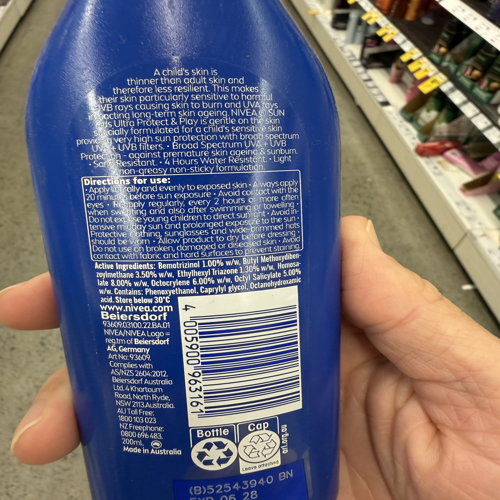

In [38]:
ds_split["train"][random_idx]["image"].resize(size=(500, 500))

In [34]:
# Upload the dataset to the Hub
ds_split.push_to_hub(repo_id="mrdbourke/sunny-skin-and-sunscreen-extract-1k",
                     private=True,
                     max_shard_size="500MB")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/987 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/110 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Uploading files as a binary IO buffer is not supported by Xet Storage. Falling back to HTTP upload.


CommitInfo(commit_url='https://huggingface.co/datasets/mrdbourke/sunny-skin-and-sunscreen-extract-1k/commit/fc95c0c4368f71221532afe108a4f0d41f5e1bf9', commit_message='Upload dataset', commit_description='', oid='fc95c0c4368f71221532afe108a4f0d41f5e1bf9', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/mrdbourke/sunny-skin-and-sunscreen-extract-1k', endpoint='https://huggingface.co', repo_type='dataset', repo_id='mrdbourke/sunny-skin-and-sunscreen-extract-1k'), pr_revision=None, pr_num=None)

Now we can easily load the dataset wherever we would like.

In [36]:
from datasets import load_dataset

ds_split_loaded = load_dataset("mrdbourke/sunny-skin-and-sunscreen-extract-1k")
ds_split_loaded

README.md:   0%|          | 0.00/545 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/181M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/24.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/987 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/110 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'input_prompt', 'output', 'source'],
        num_rows: 987
    })
    test: Dataset({
        features: ['image', 'image_id', 'input_prompt', 'output', 'source'],
        num_rows: 110
    })
})

Let's upload a README to our dataset.

In [2]:
from huggingface_hub import HfApi

# 1. Define your README content
# The section between the --- is the YAML header
readme_content = """---
dataset_info:
  features:
  - name: image
    dtype: image
  - name: image_id
    dtype: string
  - name: input_prompt
    dtype: string
  - name: output
    dtype: string
  - name: source
    dtype: string
  splits:
  - name: train
    num_bytes: 181719084.4412033
    num_examples: 987
  - name: test
    num_bytes: 24507410.55879672
    num_examples: 110
  download_size: 205644928
  dataset_size: 206226495.0
configs:
- config_name: default
  data_files:
  - split: train
    path: data/train-*
  - split: test
    path: data/test-*
---

# Sunny Dermatology Dataset (1k Sample)

This dataset contains the following: 

- 1k images from the [ISIC-2024](https://challenge2024.isic-archive.com/) permissively licensed dataset of skin lesions.
- ~100 images of front and back of sunscreen packaging taken in Australia.
- Extractions of details from each image of various details by `gemini-3-flash-preview` on February 12th 2026.

The goal of this dataset is to fine-tune a VLM (MedGemma-1.5) to reproduce the `image` + `input_prompt` -> `output` workflow.

This is part of an entry to the [MedGemma Impact Kaggle Competition](https://www.kaggle.com/competitions/med-gemma-impact-challenge).

Our app Sunny is designed to help people keep track of their skin with the goal of preventing or early detecting skin cancers.

## Dataset Structure

* `image` - PIL image of either a bottle of sunscreen (manually taken) or a sample image from the ISIC-2024 dataset.
* `image_id` - Original filename of the target image, e.g. `ISIC_3714482`.
* `input_prompt` - A simple string input to prompt the model what to extract. This is short on purpose to save on input tokens when deploying the model to device. These are: `"skin extract"` or `"sunscreen extract"`.
* `output` - The structured output desired from the model given the image + text prompt input. See below for example.
* `source` - One of `manually_taken` or `ISIC-2024` depending on where the image came from.

## Usage

```python
from datasets import load_dataset

dataset = load_dataset("mrdbourke/sunny-skin-and-sunscreen-extract-1k")
dataset
```

Output:

```
DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'input_prompt', 'output', 'source'],
        num_rows: 987
    })
    test: Dataset({
        features: ['image', 'image_id', 'input_prompt', 'output', 'source'],
        num_rows: 110
    })
})
```

## Example inputs and outputs

### Example 1

Input:

```
image of skin + "skin extract"
```

Output:

```
{'lesion_type': 'Multiple small pigmented spots or macules.',
 'color': 'Varied shades of medium to dark brown.',
 'symmetry': 'Asymmetrical in both the shape of individual spots and their overall arrangement.',
 'borders': 'Irregular and poorly defined margins.',
 'texture': 'Undetermined due to image resolution or focus.',
 'summary': 'The area shows a cluster of small, dark brown spots with irregular shapes and poorly defined edges.'}
```

### Example 2

Input:

```
image of sunscreen bottle + "sunscreen extract"
```

Output:

```
{'side': 'back',
 'formula_type': 'Chemical',
 'data': {'brand': 'NIVEA SUN',
  'product_name': 'Kids Ultra Protect & Play',
  'spf': 'Not visible',
  'spectrum': True,
  'water_resistance': 240,
  'regulatory_id': 'Art No: 93609',
  'assumed_main_ingredient': 'Homosalate',
  'active_ingredients': [{'name': 'Bemotrizinol',
    'percentage': '1.00%',
    'category': 'Chemical'},
   {'name': 'Butyl Methoxydibenzoylmethane',
    'percentage': '3.50%',
    'category': 'Chemical'},
   {'name': 'Ethylhexyl Triazone',
    'percentage': '1.30%',
    'category': 'Chemical'},
   {'name': 'Homosalate', 'percentage': '8.00%', 'category': 'Chemical'},
   {'name': 'Octocrylene', 'percentage': '6.00%', 'category': 'Chemical'},
   {'name': 'Octyl Salicylate',
    'percentage': '5.00%',
    'category': 'Chemical'}],
  'preservatives': ['Phenoxyethanol',
   'Caprylyl glycol',
   'Octanohydroxamic acid'],
  'claims': ['Very high sun protection',
   'Broad spectrum UVA + UVB filters',
   'Sand Resistant',
   '4 Hours Water Resistant',
   'Light non-greasy non-sticky formulation',
   "Specially formulated for a child's sensitive skin"],
  'application_timer': 120,
  'storage_limit': 30,
  'warnings': 'Avoid contact with the eyes. Do not expose young children to direct sunlight. Avoid intensive midday sun and prolonged exposure to the sun. Protective clothing, sunglasses and wide-brimmed hats should be worn. Allow product to dry before dressing. Do not use on broken, damaged or diseased skin. Avoid contact with fabric and hard surfaces to prevent staining.'}}
```

## Sources

* ISIC-2024 dataset: https://challenge2024.isic-archive.com/ (all images taken from SLICE-3D Permissive set).
* Manually taken images of sunscreen bottles from Australian supermarkets.
* Gemini 3 Flash labels, see prompts below for input.

## Prompts used for labelling with Gemini 3 Flash

Skin extraction:

```
Role: You are a specialized morphological observer for a skin-tracking application. 
Task: Describe the skin lesion in the provided image using a structured, narrative format.

Guidelines:
1. No Diagnosis: Do not name conditions (e.g., avoid "melanoma" or "mole").
2. No Medical Advice: Do not provide safety assessments.
3. Language: Use Sentence Case. Ensure descriptions are readable and descriptive.
4. Objectivity: Describe only what is visually present.

Extraction Schema:
{
  "lesion_type": "Description of the type (e.g., A pigmented macule/flat).",
  "color": "Description of hues and pigment distribution.",
  "symmetry": "Description of the balance of shape and color.",
  "borders": "Description of the margins/edges.",
  "texture": "Description of the surface quality.",
  "summary": "A 1-2 sentence takeaway for the user to share with a doctor."
}

Formatting Rules:
- Return ONLY valid JSON.
- If a feature is not visible due to image quality, return "Undetermined due to image resolution or focus."
```

Sunscreen extraction:

```
Role: You are a specialized dermatological data extraction agent. Your goal is to convert images of sunscreen packaging into structured JSON for a skin-health tracking app.

Task:
1. Identify Orientation: Determine if the image is "front", "back", or "other".
2. Extract Data: Capture specific fields based on the identified side.
3. Classify Formula: Based on the ingredients, classify the 'formula_type' as "Mineral", "Chemical", or "Hybrid".
4. Tag Ingredients: For each active ingredient, label it as "Mineral" or "Chemical".
5. Normalize Units: Convert all ingredient concentrations to percentages (e.g., 50mg/g = 5.0%).

Extraction Schema:
{
  "side": "front" | "back" | "other",
  "formula_type": "Mineral" | "Chemical" | "Hybrid" | "Not visible",
  "data": {
    "brand": "string",
    "product_name": "string",
    "spf": "number",
    "spectrum": "boolean",
    "water_resistance": "number (minutes)",
    "regulatory_id": "string",
    "assumed_main_ingredient": "string",
    "active_ingredients": [
      {"name": "string", "percentage": "string", "category": "Mineral" | "Chemical"}
    ],
    "preservatives": ["string"],
    "claims": ["string"],
    "application_timer": "number (minutes)",
    "storage_limit": "number (celsius)",
    "warnings": "string"
  }
}

Formatting Rules:
- Return ONLY valid JSON.
- If a field is not visible or cannot be extracted, return the string "Not visible".
- For the 'side' field, if the image is neither clearly front nor back, return "other".
```

## References

```
International Skin Imaging Collaboration. SLICE-3D 2024 Permissive Challenge Dataset. International Skin Imaging Collaboration https://doi.org/10.34970/2024-slice-3d-permissive (2024).

Creative Commons Attribution 4.0 International License.

The dataset was generated by the International Skin Imaging Collaboration (ISIC) and images are from the following sources: Memorial Sloan Kettering Cancer Center, FNQH Cairns, The University of Queensland, Melanoma Institute Australia, and University of Athens Medical School.

You should have received a copy of the license along with this work.

If not, see https://creativecommons.org/licenses/by/4.0/legalcode.txt . 
```
"""

# 2. Upload it
api = HfApi()
api.upload_file(
    path_or_fileobj=readme_content.encode("utf-8"),
    path_in_repo="README.md",
    repo_id="mrdbourke/sunny-skin-and-sunscreen-extract-1k",
    repo_type="dataset",
)

CommitInfo(commit_url='https://huggingface.co/datasets/mrdbourke/sunny-skin-and-sunscreen-extract-1k/commit/dc6ae986eab95186bb387708a741d8fc57498c68', commit_message='Upload README.md with huggingface_hub', commit_description='', oid='dc6ae986eab95186bb387708a741d8fc57498c68', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/mrdbourke/sunny-skin-and-sunscreen-extract-1k', endpoint='https://huggingface.co', repo_type='dataset', repo_id='mrdbourke/sunny-skin-and-sunscreen-extract-1k'), pr_revision=None, pr_num=None)